In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (4).zip to archive (4).zip


In [2]:
import zipfile
import os

zip_path = "/content/archive (4).zip"
extract_path = "/content/casting_project"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
train_directory = "/content/casting_project/casting_data/casting_data/train"
test_directory = "/content/casting_project/casting_data/casting_data/test"

print("Train folder:", train_directory)
print("Test folder:", test_directory)

print("\nTrain classes:", os.listdir(train_directory))
print("Test classes:", os.listdir(test_directory))

Train folder: /content/casting_project/casting_data/casting_data/train
Test folder: /content/casting_project/casting_data/casting_data/test

Train classes: ['def_front', 'ok_front']
Test classes: ['def_front', 'ok_front']


In [4]:
train_defective = len(os.listdir(os.path.join(train_directory, "def_front")))
train_good = len(os.listdir(os.path.join(train_directory, "ok_front")))

test_defective = len(os.listdir(os.path.join(test_directory, "def_front")))
test_good = len(os.listdir(os.path.join(test_directory, "ok_front")))

print("TRAIN DATA")
print("Defective images:", train_defective)
print("Non-defective images:", train_good)
print("Total training images:", train_defective + train_good)

print("\nTEST DATA")
print("Defective images:", test_defective)
print("Non-defective images:", test_good)
print("Total test images:", test_defective + test_good)

TRAIN DATA
Defective images: 3758
Non-defective images: 2875
Total training images: 6633

TEST DATA
Defective images: 453
Non-defective images: 262
Total test images: 715


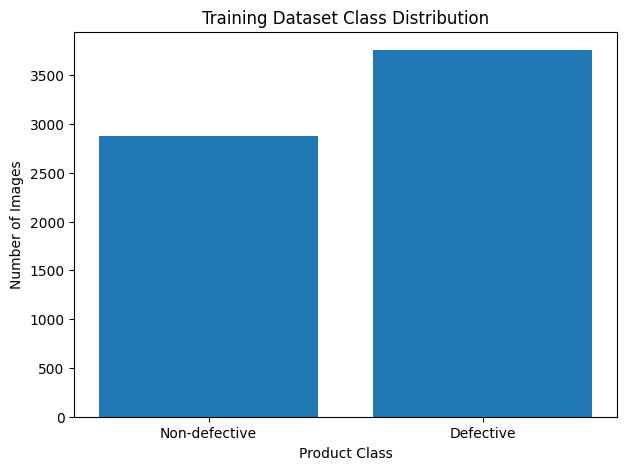

In [5]:
import matplotlib.pyplot as plt

classes = ["Non-defective", "Defective"]
train_counts = [train_good, train_defective]

plt.figure(figsize=(7, 5))
plt.bar(classes, train_counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Product Class")
plt.ylabel("Number of Images")

plt.show()

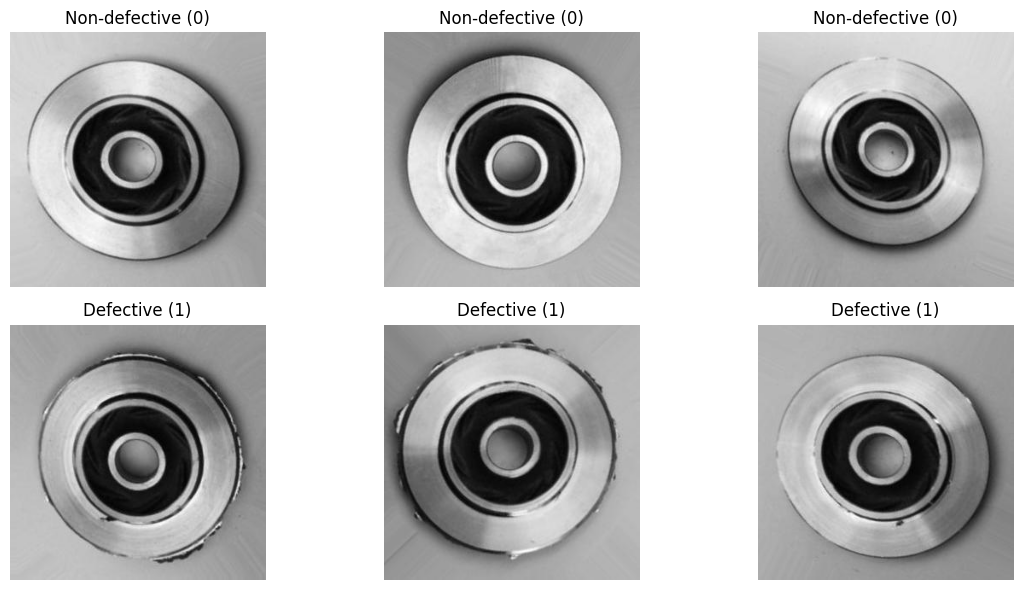

In [6]:
import random
from tensorflow.keras.utils import load_img

plt.figure(figsize=(12, 6))

# 3 non-defective images
good_folder = os.path.join(train_directory, "ok_front")
good_images = random.sample(os.listdir(good_folder), 3)

for i, image_name in enumerate(good_images):
    image_path = os.path.join(good_folder, image_name)
    image = load_img(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title("Non-defective (0)")
    plt.axis("off")

# 3 defective images
defective_folder = os.path.join(train_directory, "def_front")
defective_images = random.sample(os.listdir(defective_folder), 3)

for i, image_name in enumerate(defective_images):
    image_path = os.path.join(defective_folder, image_name)
    image = load_img(image_path)

    plt.subplot(2, 3, i + 4)
    plt.imshow(image)
    plt.title("Defective (1)")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf

image_size = (224, 224)
batch_size = 32

# IMPORTANT:
# ok_front = 0
# def_front = 1
class_names = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("\nDatasets loaded successfully!")
print("Class mapping:")
print("0 = Non-defective")
print("1 = Defective")

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.

Datasets loaded successfully!
Class mapping:
0 = Non-defective
1 = Defective


In [8]:
print("Class names:", class_names)

for images, labels in train_dataset.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("First 10 labels:", labels.numpy().flatten()[:10])

Class names: ['ok_front', 'def_front']
Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 1)
First 10 labels: [1. 0. 0. 0. 0. 0. 1. 1. 1. 1.]


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dataset prefetching enabled.")

Dataset prefetching enabled.


In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


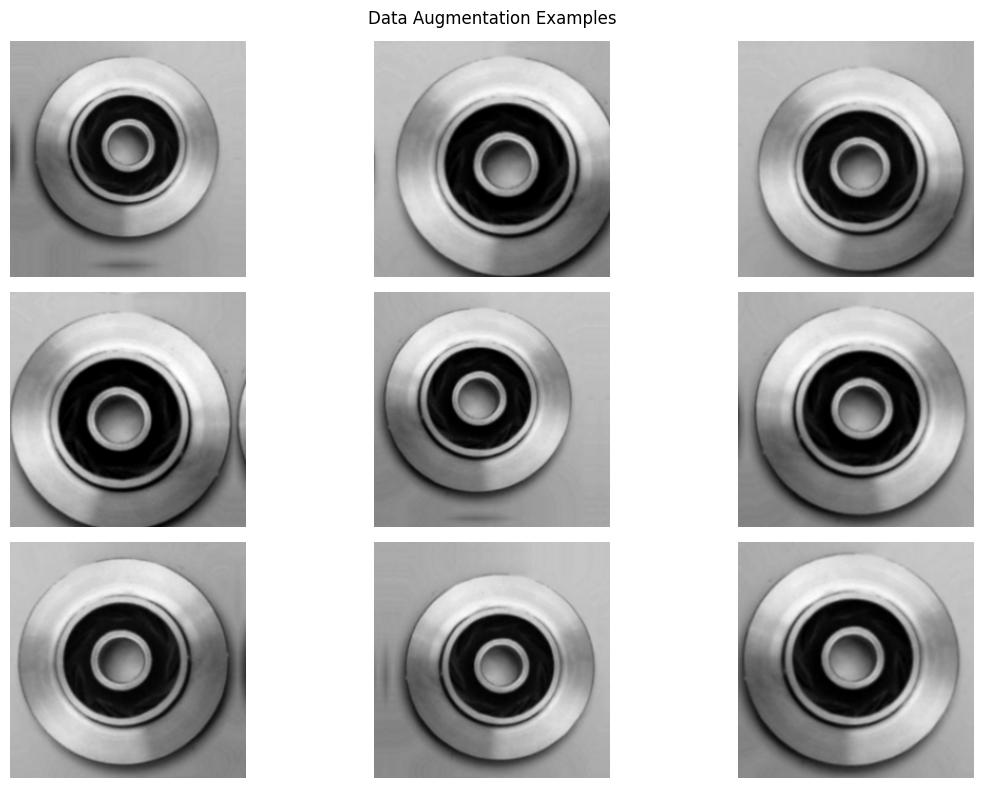

In [11]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    sample_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image[0], 0, 255),
                tf.uint8
            )
        )

        plt.axis("off")

plt.suptitle("Data Augmentation Examples")
plt.tight_layout()
plt.show()

In [12]:
from tensorflow.keras import models

model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Training augmentation
    data_augmentation,

    # Pixel normalization: 0-255 -> 0-1
    layers.Rescaling(1.0 / 255),

    # CNN Block 1
    layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # CNN Block 2
    layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # CNN Block 3
    layers.Conv2D(
        128,
        kernel_size=3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Convert feature maps to feature vector
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.40),

    # Fully connected layer
    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.30),

    # Binary classification output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("CNN model created successfully!")

CNN model created successfully!


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [15]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured successfully!")

Callbacks configured successfully!


In [16]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5557 - loss: 0.6901 - precision: 0.5663 - recall: 0.9155
Epoch 1: val_loss improved from None to 0.68098, saving model to best_casting_defect_model.keras

Epoch 1: finished saving model to best_casting_defect_model.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 737s 4s/step - accuracy: 0.5581 - loss: 0.6887 - precision: 0.5616 - recall: 0.9664 - val_accuracy: 0.5897 - val_loss: 0.6810 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5615 - loss: 0.6852 - precision: 0.5616 - recall: 0.9955
Epoch 2: val_loss improved from 0.68098 to 0.67647, saving model to best_casting_defect_model.keras

Epoch 2: finished saving model to best_casting_defect_model.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.5623 - loss: 0.6844 - precision: 0.5634 - recall: 0.9755 - val_accuracy: 0.5897 - val_loss: 0.6765 - val_precision: 0.5897 - val_recall: 1.0000 -

In [18]:
print("Available metrics:")
print(history.history.keys())

Available metrics:
dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


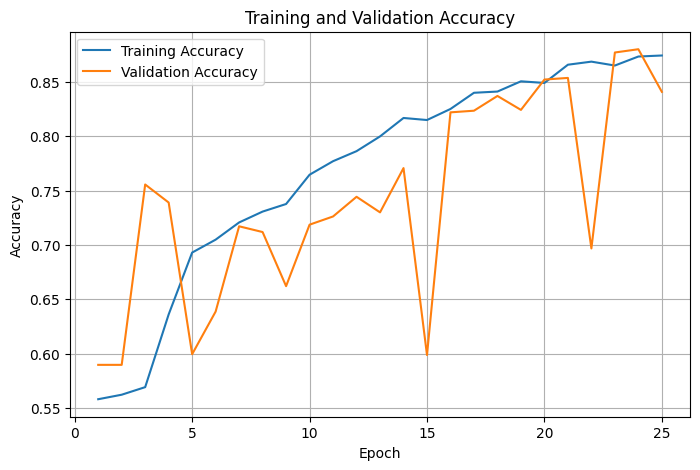

In [19]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

epochs_range = range(
    1,
    len(training_accuracy) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    validation_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

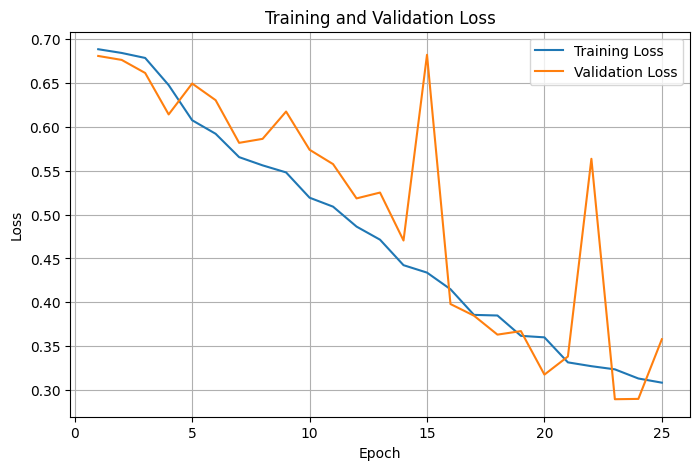

In [20]:
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
best_model = tf.keras.models.load_model(
    "best_casting_defect_model.keras"
)

print("Best trained model loaded successfully!")

Best trained model loaded successfully!


In [22]:
test_results = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results:")
print("Loss:", test_results[0])
print("Accuracy:", test_results[1])
print("Precision:", test_results[2])
print("Recall:", test_results[3])

23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8895 - loss: 0.2793 - precision: 0.9369 - recall: 0.8852

Test Results:
Loss: 0.27928218245506287
Accuracy: 0.8895105123519897
Precision: 0.9369158744812012
Recall: 0.8852097392082214


In [23]:
import numpy as np

prediction_probabilities = best_model.predict(
    test_dataset,
    verbose=1
)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.50
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print("Total predictions:", len(predicted_labels))
print("Total actual labels:", len(actual_labels))

23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 960ms/step
Total predictions: 715
Total actual labels: 715


In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "Non-defective",
            "Defective"
        ],
        digits=4
    )
)

               precision    recall  f1-score   support

Non-defective     0.8188    0.8969    0.8561       262
    Defective     0.9369    0.8852    0.9103       453

     accuracy                         0.8895       715
    macro avg     0.8779    0.8911    0.8832       715
 weighted avg     0.8936    0.8895    0.8905       715



In [25]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(matrix)


Confusion Matrix:
[[235  27]
 [ 52 401]]


In [26]:
tn, fp, fn, tp = matrix.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 235
False Positives: 27
False Negatives: 52
True Positives : 401


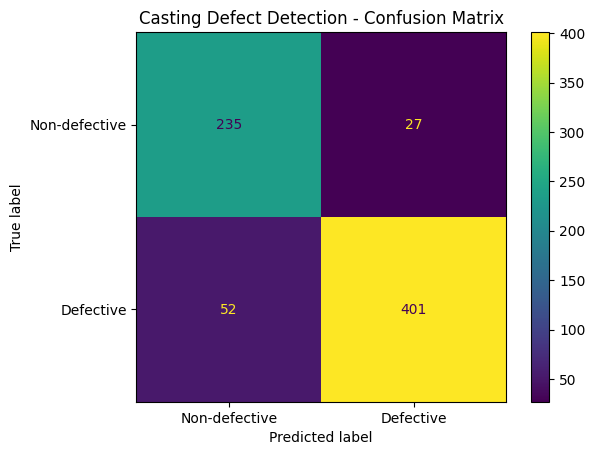

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        "Non-defective",
        "Defective"
    ]
)

display.plot(
    values_format="d"
)

plt.title("Casting Defect Detection - Confusion Matrix")
plt.show()

In [28]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0

recall = tp / (tp + fn) if (tp + fn) > 0 else 0

false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"False Positive Rate: {false_positive_rate:.2%}")
print(f"False Negative Rate: {false_negative_rate:.2%}")

Accuracy: 88.95%
Precision: 93.69%
Recall: 88.52%
False Positive Rate: 10.31%
False Negative Rate: 11.48%


In [29]:
print("MODEL EVALUATION SUMMARY")
print("-" * 40)

print(f"Test Accuracy      : {accuracy:.2%}")
print(f"Defect Precision   : {precision:.2%}")
print(f"Defect Recall      : {recall:.2%}")

print(f"\nTrue Negatives     : {tn}")
print(f"False Positives    : {fp}")
print(f"False Negatives    : {fn}")
print(f"True Positives     : {tp}")

print("\nQuality Control Interpretation:")

if fn == 0:
    print("Excellent: No defective products were missed.")
else:
    print(
        f"{fn} defective product(s) were incorrectly classified "
        "as non-defective."
    )

print(
    "False negatives are important because defective products "
    "could pass quality inspection."
)

MODEL EVALUATION SUMMARY
----------------------------------------
Test Accuracy      : 88.95%
Defect Precision   : 93.69%
Defect Recall      : 88.52%

True Negatives     : 235
False Positives    : 27
False Negatives    : 52
True Positives     : 401

Quality Control Interpretation:
52 defective product(s) were incorrectly classified as non-defective.
False negatives are important because defective products could pass quality inspection.


In [30]:
def predict_product(image_path, model, threshold=0.50):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, axis=0)

    defect_probability = float(
        model.predict(image_array, verbose=0)[0][0]
    )

    if defect_probability >= threshold:
        predicted_class = "Defective"
        recommended_action = "Send for manual inspection"
    else:
        predicted_class = "Non-defective"
        recommended_action = "Product may proceed"

    print(f"Prediction: {predicted_class}")
    print(f"Defect probability: {defect_probability:.2%}")
    print(f"Decision threshold: {threshold:.0%}")
    print(f"Recommended action: {recommended_action}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"{predicted_class}\n"
        f"Defect Probability: {defect_probability:.2%}"
    )
    plt.axis("off")
    plt.show()

Prediction: Defective
Defect probability: 55.75%
Decision threshold: 50%
Recommended action: Send for manual inspection


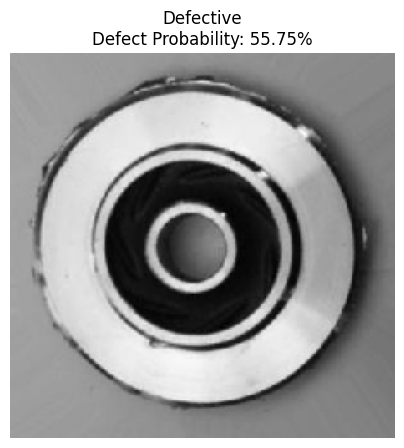

In [31]:
sample_image_path = os.path.join(
    test_directory,
    "def_front",
    os.listdir(
        os.path.join(test_directory, "def_front")
    )[0]
)

predict_product(
    sample_image_path,
    best_model,
    threshold=0.50
)

In [32]:
import random

test_samples = []

good_test_folder = os.path.join(
    test_directory,
    "ok_front"
)

def_test_folder = os.path.join(
    test_directory,
    "def_front"
)

# 2 good images
for image_name in random.sample(
    os.listdir(good_test_folder),
    2
):
    test_samples.append(
        (
            os.path.join(good_test_folder, image_name),
            0,
            "Non-defective"
        )
    )

# 3 defective images
for image_name in random.sample(
    os.listdir(def_test_folder),
    3
):
    test_samples.append(
        (
            os.path.join(def_test_folder, image_name),
            1,
            "Defective"
        )
    )

random.shuffle(test_samples)

print("5 unseen test images selected.")

5 unseen test images selected.


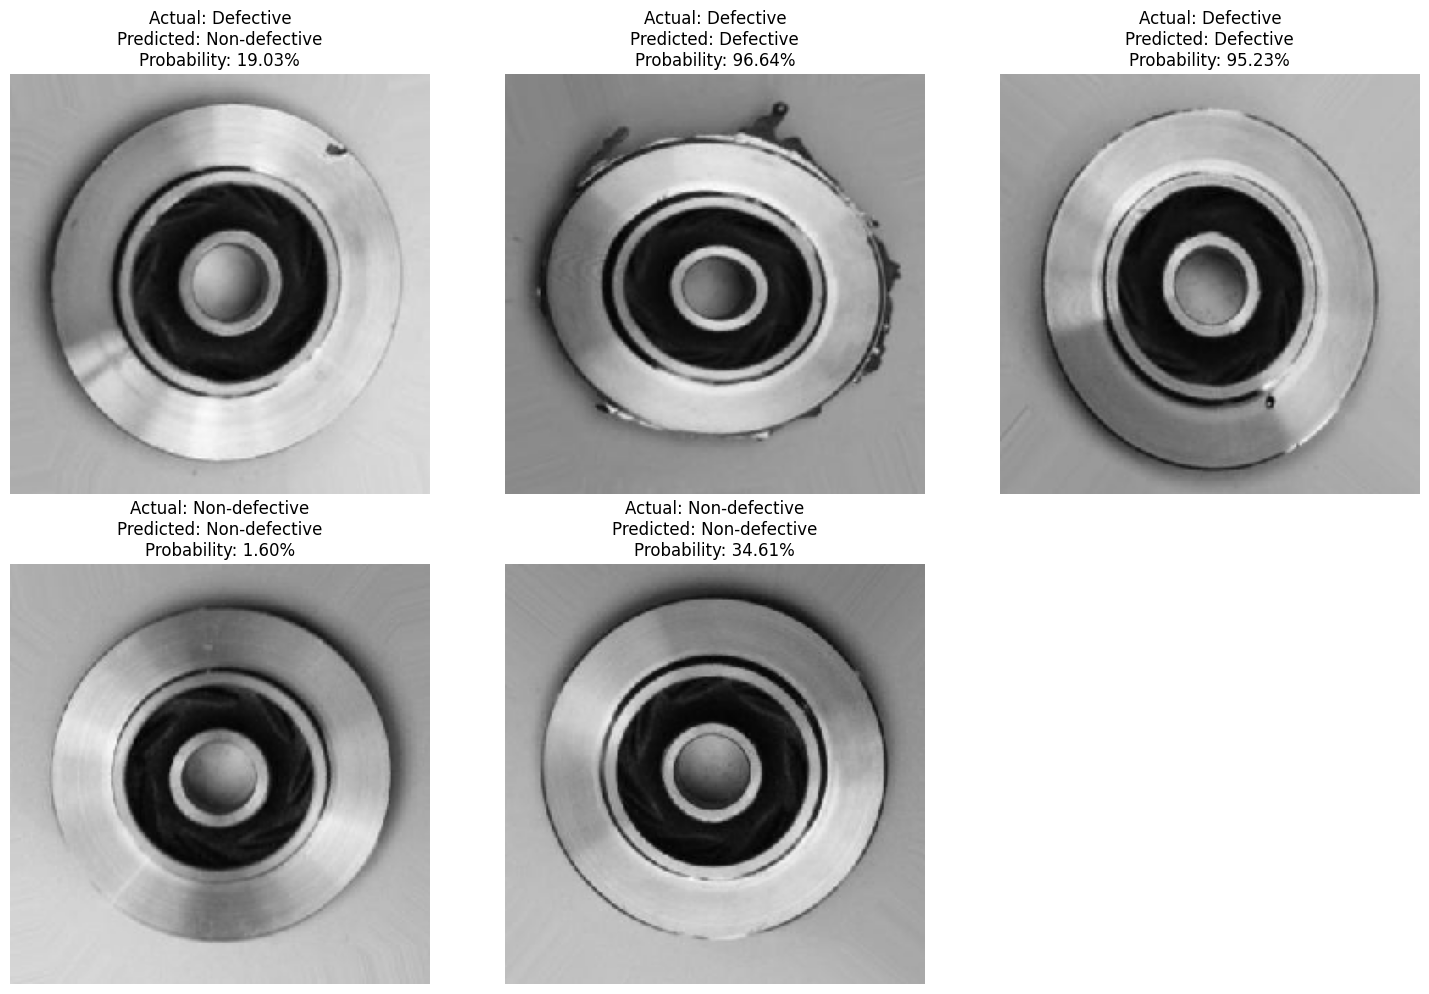

In [33]:
results = []

plt.figure(figsize=(15, 10))

for i, (image_path, actual_label, actual_name) in enumerate(
    test_samples
):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_batch = tf.expand_dims(image_array, axis=0)

    probability = float(
        best_model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    predicted_label = 1 if probability >= 0.50 else 0

    predicted_name = (
        "Defective"
        if predicted_label == 1
        else "Non-defective"
    )

    correct = (
        "Yes"
        if predicted_label == actual_label
        else "No"
    )

    results.append({
        "Image": os.path.basename(image_path),
        "Actual": actual_name,
        "Prediction": predicted_name,
        "Defect Probability": probability,
        "Correct": correct
    })

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Probability: {probability:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df["Defect Probability"] = (
    results_df["Defect Probability"]
    .apply(lambda x: f"{x:.2%}")
)

results_df

,Image,Actual,Prediction,Defect Probability,Correct
0,cast_def_0_1539.jpeg,Defective,Non-defective,19.03%,No
1,cast_def_0_1260.jpeg,Defective,Defective,96.64%,Yes
2,cast_def_0_1500.jpeg,Defective,Defective,95.23%,Yes
3,cast_ok_0_7946.jpeg,Non-defective,Non-defective,1.60%,Yes
4,cast_ok_0_7925.jpeg,Non-defective,Non-defective,34.61%,Yes


In [35]:
thresholds = [
    0.30,
    0.40,
    0.50,
    0.60
]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

threshold_results = []

for threshold in thresholds:

    labels_at_threshold = (
        prediction_probabilities.flatten()
        >= threshold
    ).astype(int)

    acc = accuracy_score(
        actual_labels,
        labels_at_threshold
    )

    prec = precision_score(
        actual_labels,
        labels_at_threshold,
        zero_division=0
    )

    rec = recall_score(
        actual_labels,
        labels_at_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall
0,0.3,0.874126,0.872690,0.938190
1,0.4,0.878322,0.896104,0.913907
2,0.5,0.889510,0.936916,0.885210
3,0.6,0.876923,0.964377,0.836645


In [36]:
best_model.save(
    "casting_defect_detection_final.keras"
)

print(
    "Final model saved as "
    "casting_defect_detection_final.keras"
)

Final model saved as casting_defect_detection_final.keras


In [37]:
print("=" * 60)
print("AUTOMATED CASTING DEFECT DETECTION - FINAL RESULTS")
print("=" * 60)

print("\nDATASET")
print(f"Training Images (original folder): {train_good + train_defective}")
print(f"Testing Images: {test_good + test_defective}")
print("Image Size: 224 x 224")
print("Batch Size: 32")

print("\nCLASS LABELS")
print("0 = Non-defective")
print("1 = Defective")

print("\nMODEL PERFORMANCE")
print(f"Test Accuracy : {accuracy:.2%}")
print(f"Precision     : {precision:.2%}")
print(f"Recall        : {recall:.2%}")

print("\nCONFUSION MATRIX")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

print("\nQUALITY CONTROL ANALYSIS")

if fn == 0:
    print("No defective products were missed by the model.")
else:
    print(
        f"The model missed {fn} defective product(s). "
        "These false negatives are particularly important "
        "in an industrial quality-control environment."
    )

print("=" * 60)

AUTOMATED CASTING DEFECT DETECTION - FINAL RESULTS

DATASET
Training Images (original folder): 6633
Testing Images: 715
Image Size: 224 x 224
Batch Size: 32

CLASS LABELS
0 = Non-defective
1 = Defective

MODEL PERFORMANCE
Test Accuracy : 88.95%
Precision     : 93.69%
Recall        : 88.52%

CONFUSION MATRIX
True Negatives  : 235
False Positives : 27
False Negatives : 52
True Positives  : 401

QUALITY CONTROL ANALYSIS
The model missed 52 defective product(s). These false negatives are particularly important in an industrial quality-control environment.


## Project Findings

The objective of this project was to develop a Convolutional Neural Network (CNN) capable of automatically classifying casting product images as defective or non-defective.

The dataset contained two classes:

- **Non-defective (0):** `ok_front`
- **Defective (1):** `def_front`

The original training folder contained 6,633 images, including 2,875 non-defective images and 3,758 defective images. A validation dataset was created from 20% of the training data. The separate test dataset contained 715 images.

All images were resized to 224 × 224 pixels. Pixel normalization was incorporated into the CNN using a rescaling layer.

Mild data augmentation was applied during training, including horizontal flipping, rotation, zoom, translation, and contrast adjustment. Augmentation was not applied during validation or testing.

A custom CNN containing three convolutional layers was developed. Max-pooling layers were used to reduce spatial dimensions, while dropout was included to reduce overfitting. The final layer contained one neuron with sigmoid activation for binary classification.

The model was trained using the Adam optimizer and binary cross-entropy loss. Early stopping, learning-rate reduction, and model checkpointing were used to improve training stability and preserve the best-performing model.

The final model was evaluated using accuracy, precision, recall, a classification report, and a confusion matrix.

In this quality-control application, recall for the defective class is particularly important. A false negative occurs when a defective product is incorrectly classified as non-defective. Such errors could allow defective products to pass inspection and therefore should be minimized.

Testing on unseen images demonstrated how the trained CNN can classify new casting products and provide a defect probability that can support automated or manual inspection decisions.

## Conclusion

This project demonstrates how convolutional neural networks can be applied to automated industrial quality inspection.

The CNN learned visual characteristics from casting product images and classified products into defective and non-defective categories. Data augmentation and dropout were used to improve generalization, while early stopping and learning-rate reduction helped control the training process.

The confusion matrix and classification metrics provide a more complete evaluation than accuracy alone. In particular, false negatives must be carefully monitored because failing to detect a defective component can have greater consequences than unnecessarily inspecting a non-defective component.

The trained model can accept a previously unseen casting image and generate a defect probability. Based on a selected classification threshold, the system can recommend whether the product should proceed or be sent for manual inspection.

Future improvements could include transfer learning, class weighting, threshold optimization, Grad-CAM visualization, and deployment through a web or Streamlit application.

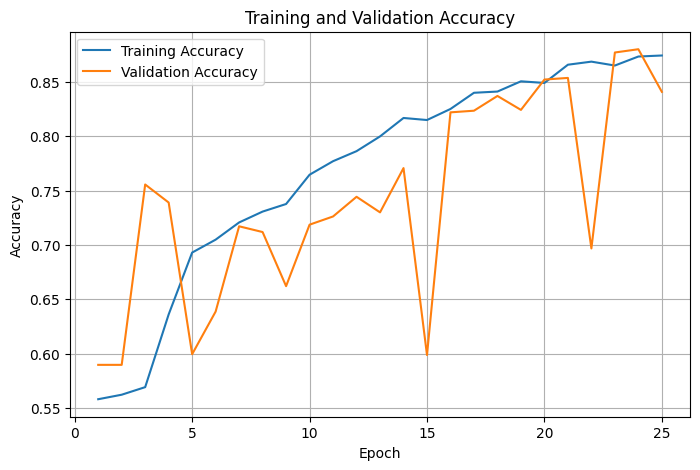

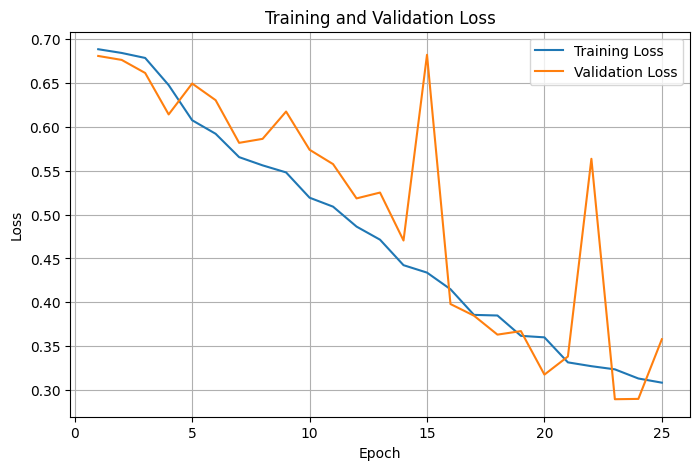

Graphs saved successfully.


In [38]:
# Accuracy Graph

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    validation_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "accuracy_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Loss Graph

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    training_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "loss_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graphs saved successfully.")

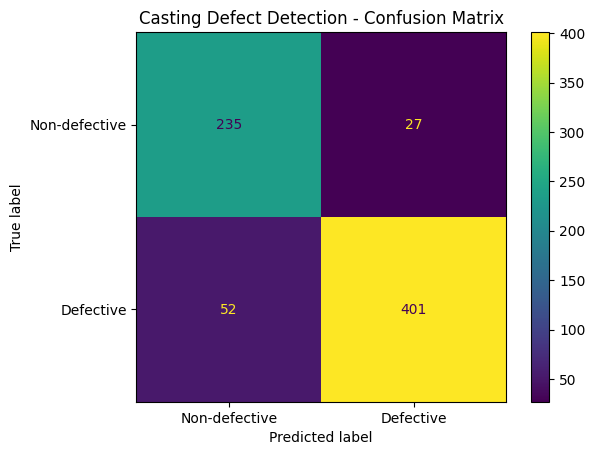

Confusion matrix saved successfully.


In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        "Non-defective",
        "Defective"
    ]
)

display.plot(values_format="d")

plt.title(
    "Casting Defect Detection - Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")

In [40]:
requirements = """tensorflow
numpy
matplotlib
pandas
scikit-learn
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [41]:
readme = """
# Automated Casting Defect Detection Using CNN

## Project Overview

This project uses a Convolutional Neural Network (CNN) to classify
casting product images as defective or non-defective.

## Classes

0 = Non-defective
1 = Defective

## Image Size

224 x 224 pixels

## Model

The CNN contains:

- Data augmentation
- Image normalization
- Three Conv2D layers
- MaxPooling layers
- Global Average Pooling
- Dropout
- Dense layer
- Sigmoid output layer

## Training

Optimizer: Adam

Learning Rate: 0.001

Loss Function: Binary Cross-Entropy

Batch Size: 32

Maximum Epochs: 25

## Regularization

The project uses:

- Data augmentation
- Dropout
- Early stopping
- ReduceLROnPlateau
- Model checkpointing

## Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- False positives
- False negatives

Recall for defective products is particularly important because
false negatives could allow defective products to pass inspection.

## Running the Project

1. Install the required Python libraries.

   pip install -r requirements.txt

2. Place the casting dataset inside the data directory.

3. Run the Jupyter Notebook or Google Colab notebook.

4. Train the CNN.

5. Evaluate the model using the separate test dataset.

6. Use the prediction function to classify unseen casting images.

## Output

The system produces:

- Product classification
- Defect probability
- Decision threshold
- Recommended inspection action

## Saved Model

The final trained model is stored as:

casting_defect_detection_final.keras
"""

with open("README.md", "w") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [42]:
import os

files_to_check = [
    "best_casting_defect_model.keras",
    "casting_defect_detection_final.keras",
    "accuracy_graph.png",
    "loss_graph.png",
    "confusion_matrix.png",
    "requirements.txt",
    "README.md"
]

print("FINAL PROJECT FILES")
print("=" * 50)

for filename in files_to_check:
    if os.path.exists(filename):
        size = os.path.getsize(filename) / (1024 * 1024)

        print(
            f"✓ {filename} "
            f"({size:.2f} MB)"
        )
    else:
        print(f"✗ Missing: {filename}")

FINAL PROJECT FILES
✓ best_casting_defect_model.keras (1.23 MB)
✓ casting_defect_detection_final.keras (1.23 MB)
✓ accuracy_graph.png (0.17 MB)
✓ loss_graph.png (0.16 MB)
✓ confusion_matrix.png (0.09 MB)
✓ requirements.txt (0.00 MB)
✓ README.md (0.00 MB)


In [43]:
from google.colab import files

files.download(
    "casting_defect_detection_final.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import os
import zipfile
from google.colab import files

# Files to include
project_files = [
    "README.md",
    "accuracy_graph.png",
    "best_casting_defect_model.keras",
    "casting_defect_detection_final.keras",
    "confusion_matrix.png",
    "loss_graph.png",
    "requirements.txt"
]

zip_name = "casting_quality_inspection_project.zip"

# Create ZIP
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_name in project_files:
        if os.path.exists(file_name):
            zipf.write(file_name)
            print(f"Added: {file_name}")
        else:
            print(f"Missing: {file_name}")

print("\nZIP created successfully:", zip_name)

# Download ZIP
files.download(zip_name)

Added: README.md
Added: accuracy_graph.png
Added: best_casting_defect_model.keras
Added: casting_defect_detection_final.keras
Added: confusion_matrix.png
Added: loss_graph.png
Added: requirements.txt

ZIP created successfully: casting_quality_inspection_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>